# Test 9.1: Coefficient Combination — Original vs Optimized

**Гипотеза:** Комбинация оптимальных коэффициентов (a=4, w=1.0, b=16), найденных при одномерной абляции в Test 9, даёт лучшую дисперсию чем текущие (a=8, w=0.5, b=4) при сохранении zero dead neurons на всех доменах.

**Конфигурации:**
- **Original:** sin(8x) + 0.5·tanh(4x) — текущие коэффициенты
- **Optimized:** sin(4x) + 1.0·tanh(16x) — оптимальные из Test 9
- **TopK_ReLU:** baseline для сравнения (те же K=32)

**Часть A: Multi-domain** (по мотивам Test 8_lorenz96)
- Логистическая карта (5K train)
- Лоренц-96 (5K train)
- MNIST (60K train)
- N=10 прогонов, Welch t-test

**Часть B: Dataset scaling** (по мотивам Test 8_dataset_scaling)
- Логистическая карта: 2K, 5K, 10K, 20K
- Original vs Optimized
- N=10 прогонов

In [1]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
from scipy import stats
import json
from datetime import datetime

print(f"TF version: {tf.__version__}")
print(f"GPU: {tf.config.list_physical_devices('GPU')}")

/Users/savenkovviktor/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


TF version: 2.16.2
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
class KSparseLayer(layers.Layer):
    def __init__(self, k=32, **kwargs):
        super().__init__(**kwargs)
        self.k = k

    def call(self, inputs, training=None):
        latent_dim = tf.shape(inputs)[1]
        _, indices = tf.nn.top_k(tf.abs(inputs), k=self.k, sorted=False)
        mask = tf.reduce_sum(
            tf.one_hot(indices, latent_dim, dtype=inputs.dtype), axis=1
        )
        return inputs * mask

    def get_config(self):
        config = super().get_config()
        config.update({"k": self.k})
        return config


def make_chaos_activation(a=8.0, w=0.5, b=4.0):
    @tf.function
    def activation(x):
        return tf.sin(a * x) + w * tf.tanh(b * x)
    return activation


# Two coefficient sets
ORIGINAL = {'a': 8.0, 'w': 0.5, 'b': 4.0, 'label': 'Original (8, 0.5, 4)'}
OPTIMIZED = {'a': 4.0, 'w': 1.0, 'b': 16.0, 'label': 'Optimized (4, 1.0, 16)'}


def build_ksparse_ae(a=8.0, w=0.5, b=4.0,
                     image_size=(28, 28), latent_dim=128, k_active=32):
    act = make_chaos_activation(a, w, b)
    input_img = keras.Input(shape=(*image_size, 1))
    x = layers.Flatten()(input_img)
    x = layers.Dense(256)(x)
    x = layers.Activation(act)(x)
    x = layers.Dropout(0.2)(x)
    x = layers.Dense(latent_dim, name='latent_pre')(x)
    x = layers.Activation(act)(x)
    latent = KSparseLayer(k=k_active, name='latent_ksparse')(x)
    encoder = keras.Model(input_img, latent, name='encoder')

    x = layers.Dense(256)(latent)
    x = layers.BatchNormalization()(x)
    x = layers.Activation(act)(x)
    x = layers.Dropout(0.1)(x)
    decoded = layers.Dense(np.prod(image_size), activation='sigmoid')(x)
    decoded = layers.Reshape((*image_size, 1))(decoded)

    autoencoder = keras.Model(input_img, decoded)
    autoencoder.compile(optimizer='adam', loss='mse')
    return autoencoder, encoder


def build_topk_relu_ae(image_size=(28, 28), latent_dim=128, k_active=32):
    input_img = keras.Input(shape=(*image_size, 1))
    x = layers.Flatten()(input_img)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.2)(x)
    x = layers.Dense(latent_dim, activation='relu', name='latent_pre')(x)
    latent = KSparseLayer(k=k_active, name='latent_ksparse')(x)
    encoder = keras.Model(input_img, latent, name='encoder')

    x = layers.Dense(256, activation='relu')(latent)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.1)(x)
    decoded = layers.Dense(np.prod(image_size), activation='sigmoid')(x)
    decoded = layers.Reshape((*image_size, 1))(decoded)

    autoencoder = keras.Model(input_img, decoded)
    autoencoder.compile(optimizer='adam', loss='mse')
    return autoencoder, encoder


def analyze_latent(encoder, images, threshold=1e-6):
    latents = encoder.predict(images, verbose=0)
    variance_per_dim = np.var(latents, axis=0)
    dead_mask = np.all(np.abs(latents) < threshold, axis=0)
    zero_mask = np.abs(latents) < threshold
    return {
        'mean_variance': float(np.mean(variance_per_dim)),
        'dead_neurons': int(np.sum(dead_mask)),
        'total_neurons': latents.shape[1],
        'sparsity': float(np.mean(zero_mask)),
    }


print("Core components ready.")
print(f"Original:  sin({ORIGINAL['a']}x) + {ORIGINAL['w']}*tanh({ORIGINAL['b']}x)")
print(f"Optimized: sin({OPTIMIZED['a']}x) + {OPTIMIZED['w']}*tanh({OPTIMIZED['b']}x)")

Core components ready.
Original:  sin(8.0x) + 0.5*tanh(4.0x)
Optimized: sin(4.0x) + 1.0*tanh(16.0x)


In [ ]:
def lorenz96_rk4_step(x, F, dt):
    """One RK4 step for Lorenz-96."""
    N = len(x)
    def deriv(state):
        d = np.empty(N)
        for i in range(N):
            d[i] = (state[(i+1) % N] - state[(i-2) % N]) * state[(i-1) % N] - state[i] + F
        return d
    k1 = deriv(x)
    k2 = deriv(x + 0.5*dt*k1)
    k3 = deriv(x + 0.5*dt*k2)
    k4 = deriv(x + dt*k3)
    return x + (dt/6.0)*(k1 + 2*k2 + 2*k3 + k4)


def generate_lorenz96_dataset(num_images, state_dim=40, image_size=28,
                               F=8.0, dt=0.05, spinup_steps=200):
    """
    Generate images from Lorenz-96 system.
    
    Strategy: many independent short trajectories (like logistic map generator).
    Each image = 784 consecutive x_0(t) values from one trajectory.
    """
    pixels_per_image = image_size * image_size  # 784
    images = []
    
    for img_idx in range(num_images):
        # Random initial condition near the attractor
        x = F * np.ones(state_dim) + np.random.randn(state_dim) * 0.5
        
        # Spinup to reach attractor
        for _ in range(spinup_steps):
            x = lorenz96_rk4_step(x, F, dt)
        
        # Collect trajectory (first variable only)
        signal = np.empty(pixels_per_image)
        for step in range(pixels_per_image):
            x = lorenz96_rk4_step(x, F, dt)
            signal[step] = x[0]
        
        # Normalize to [0, 1]
        sig_min, sig_max = signal.min(), signal.max()
        signal = (signal - sig_min) / (sig_max - sig_min + 1e-8)
        images.append(signal.reshape(image_size, image_size))
        
        if (img_idx + 1) % 1000 == 0:
            print(f"  Generated {img_idx+1}/{num_images} images")
    
    images = np.array(images)[..., np.newaxis].astype('float32')
    print(f"Generated {num_images} Lorenz-96 images {images.shape}, "
          f"pixel range: [{images.min():.3f}, {images.max():.3f}]")
    return images


# Logistic map for comparison
def logistic_map(x, r=3.99):
    return r * x * (1 - x)

def generate_logistic_dataset(num_images, image_size=28, r=3.99):
    dataset = []
    for _ in range(num_images):
        x = np.random.rand()
        seq = []
        for _ in range(image_size * image_size):
            x = logistic_map(x, r)
            seq.append(x)
        dataset.append(np.array(seq).reshape(image_size, image_size))
    return np.array(dataset)[..., np.newaxis].astype('float32')


print("Data generators ready.")

Data generators ready.


In [ ]:
NUM_RUNS = 10
EPOCHS = 10
LATENT_DIM = 128
K_ACTIVE = 32


def run_config(builder_fn, train_data, test_data, label,
               num_runs=NUM_RUNS, batch_size=64):
    runs = []
    for run in range(num_runs):
        np.random.seed(run)
        tf.random.set_seed(run)

        ae, enc = builder_fn()
        history = ae.fit(
            train_data, train_data,
            epochs=EPOCHS, batch_size=batch_size,
            validation_split=0.1, verbose=0
        )
        s = analyze_latent(enc, test_data)
        s['val_loss'] = float(history.history['val_loss'][-1])
        runs.append(s)
        print(f"  {label:35s} run {run+1}/{num_runs}: "
              f"var={s['mean_variance']:.4f}, "
              f"dead={s['dead_neurons']:>3d}/128, "
              f"loss={s['val_loss']:.4f}")

        del ae, enc
        keras.backend.clear_session()

    return runs


print(f"Config: N={NUM_RUNS}, epochs={EPOCHS}, latent={LATENT_DIM}, K={K_ACTIVE}")

Config: N=10, epochs=10, latent=128, K=32


---
## Part A: Multi-Domain Comparison
---

In [ ]:
TRAIN_SIZE = 5000
TEST_SIZE = 500

# Logistic map
np.random.seed(42)
logistic_train = generate_logistic_dataset(TRAIN_SIZE)
np.random.seed(999)
logistic_test = generate_logistic_dataset(TEST_SIZE)
print(f"Logistic: train={logistic_train.shape}, test={logistic_test.shape}")

# Lorenz-96
np.random.seed(42)
lorenz_train = generate_lorenz96_dataset(TRAIN_SIZE)
np.random.seed(999)
lorenz_test = generate_lorenz96_dataset(TEST_SIZE)
print(f"Lorenz96: train={lorenz_train.shape}, test={lorenz_test.shape}")

# MNIST
(mnist_train, _), (mnist_test, _) = keras.datasets.mnist.load_data()
mnist_train = mnist_train.astype('float32')[..., np.newaxis] / 255.0
mnist_test = mnist_test.astype('float32')[..., np.newaxis] / 255.0
print(f"MNIST:    train={mnist_train.shape}, test={mnist_test.shape}")

Logistic: train=(5000, 28, 28, 1), test=(500, 28, 28, 1)
  Generated 1000/5000 images
  Generated 2000/5000 images
  Generated 3000/5000 images
  Generated 4000/5000 images
  Generated 5000/5000 images
Generated 5000 Lorenz-96 images (5000, 28, 28, 1), pixel range: [0.000, 1.000]
Generated 500 Lorenz-96 images (500, 28, 28, 1), pixel range: [0.000, 1.000]
Lorenz96: train=(5000, 28, 28, 1), test=(500, 28, 28, 1)
MNIST:    train=(60000, 28, 28, 1), test=(10000, 28, 28, 1)


In [ ]:
domains = {
    'Logistic': (logistic_train, logistic_test, 64),
    'Lorenz96': (lorenz_train, lorenz_test, 64),
    'MNIST':    (mnist_train, mnist_test, 128),
}

architectures = {
    'Original':  lambda: build_ksparse_ae(a=8.0, w=0.5, b=4.0,
                                          latent_dim=LATENT_DIM, k_active=K_ACTIVE),
    'Optimized': lambda: build_ksparse_ae(a=4.0, w=1.0, b=16.0,
                                          latent_dim=LATENT_DIM, k_active=K_ACTIVE),
    'TopK_ReLU': lambda: build_topk_relu_ae(latent_dim=LATENT_DIM, k_active=K_ACTIVE),
}

results_a = {}

for domain_name, (train_data, test_data, batch_size) in domains.items():
    print(f"\n{'='*70}")
    print(f"DOMAIN: {domain_name}")
    print(f"{'='*70}")
    results_a[domain_name] = {}

    for arch_name, builder in architectures.items():
        print(f"\n  --- {arch_name} ---")
        results_a[domain_name][arch_name] = run_config(
            builder, train_data, test_data,
            f"{domain_name}/{arch_name}",
            batch_size=batch_size
        )

print("\nPart A done.")


DOMAIN: Logistic

  --- Original ---


2026-02-28 18:22:46.150465: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4 Pro
2026-02-28 18:22:46.150488: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 48.00 GB
2026-02-28 18:22:46.150491: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 18.00 GB
2026-02-28 18:22:46.150510: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-02-28 18:22:46.150520: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)
2026-02-28 18:22:46.559850: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


  Logistic/Original                   run 1/10: var=0.4089, dead=  0/128, loss=0.1166
  Logistic/Original                   run 2/10: var=0.4130, dead=  0/128, loss=0.1167
  Logistic/Original                   run 3/10: var=0.4153, dead=  0/128, loss=0.1167
  Logistic/Original                   run 4/10: var=0.4178, dead=  0/128, loss=0.1166
  Logistic/Original                   run 5/10: var=0.4138, dead=  0/128, loss=0.1167
  Logistic/Original                   run 6/10: var=0.4169, dead=  0/128, loss=0.1166
  Logistic/Original                   run 7/10: var=0.4122, dead=  0/128, loss=0.1167
  Logistic/Original                   run 8/10: var=0.4141, dead=  0/128, loss=0.1167
  Logistic/Original                   run 9/10: var=0.4120, dead=  0/128, loss=0.1167
  Logistic/Original                   run 10/10: var=0.4062, dead=  0/128, loss=0.1166

  --- Optimized ---
  Logistic/Optimized                  run 1/10: var=0.7814, dead=  0/128, loss=0.1173
  Logistic/Optimized            

In [ ]:
print(f"\n{'='*90}")
print(f"PART A: MULTI-DOMAIN COMPARISON (N={NUM_RUNS} runs)")
print(f"{'='*90}")

summary_a_table = {}

for domain_name in domains:
    print(f"\n--- {domain_name} ---")
    print(f"  {'Architecture':<20} {'Variance':>16} {'Dead':>12} {'Val Loss':>14}")
    print(f"  {'-'*65}")

    summary_a_table[domain_name] = {}

    for arch_name in architectures:
        runs = results_a[domain_name][arch_name]
        v = [r['mean_variance'] for r in runs]
        d = [r['dead_neurons'] for r in runs]
        l = [r['val_loss'] for r in runs]

        row = {
            'var_mean': np.mean(v), 'var_std': np.std(v),
            'dead_mean': np.mean(d), 'dead_std': np.std(d),
            'loss_mean': np.mean(l), 'loss_std': np.std(l),
        }
        summary_a_table[domain_name][arch_name] = row

        print(f"  {arch_name:<20} "
              f"{row['var_mean']:.4f} ± {row['var_std']:.4f} "
              f"{row['dead_mean']:>5.1f} ± {row['dead_std']:.1f} "
              f"{row['loss_mean']:.4f} ± {row['loss_std']:.4f}")

    # Statistical tests: Original vs Optimized
    orig_v = [r['mean_variance'] for r in results_a[domain_name]['Original']]
    opt_v = [r['mean_variance'] for r in results_a[domain_name]['Optimized']]
    t_stat, p_val = stats.ttest_ind(orig_v, opt_v, equal_var=False)
    ratio = np.mean(opt_v) / np.mean(orig_v)
    sig = '***' if p_val < 0.001 else ('**' if p_val < 0.01 else ('*' if p_val < 0.05 else 'ns'))
    print(f"\n  Original vs Optimized: ratio={ratio:.2f}x, p={p_val:.6f} ({sig})")

    # Loss comparison
    orig_l = [r['val_loss'] for r in results_a[domain_name]['Original']]
    opt_l = [r['val_loss'] for r in results_a[domain_name]['Optimized']]
    t_stat_l, p_val_l = stats.ttest_ind(orig_l, opt_l, equal_var=False)
    loss_diff = (np.mean(opt_l) / np.mean(orig_l) - 1) * 100
    sig_l = '***' if p_val_l < 0.001 else ('**' if p_val_l < 0.01 else ('*' if p_val_l < 0.05 else 'ns'))
    print(f"  Loss difference: {loss_diff:+.2f}%, p={p_val_l:.6f} ({sig_l})")


PART A: MULTI-DOMAIN COMPARISON (N=10 runs)

--- Logistic ---
  Architecture                 Variance         Dead       Val Loss
  -----------------------------------------------------------------
  Original             0.4130 ± 0.0033   0.0 ± 0.0 0.1167 ± 0.0000
  Optimized            0.7845 ± 0.0090   0.0 ± 0.0 0.1173 ± 0.0000
  TopK_ReLU            1.1503 ± 0.1193  16.8 ± 4.4 0.1129 ± 0.0004

  Original vs Optimized: ratio=1.90x, p=0.000000 (***)
  Loss difference: +0.55%, p=0.000000 (***)

--- Lorenz96 ---
  Architecture                 Variance         Dead       Val Loss
  -----------------------------------------------------------------
  Original             0.4125 ± 0.0032   0.0 ± 0.0 0.0432 ± 0.0001
  Optimized            0.7723 ± 0.0109   0.0 ± 0.0 0.0436 ± 0.0000
  TopK_ReLU            1.8164 ± 0.1076  16.9 ± 4.5 0.0334 ± 0.0009

  Original vs Optimized: ratio=1.87x, p=0.000000 (***)
  Loss difference: +0.96%, p=0.000000 (***)

--- MNIST ---
  Architecture                

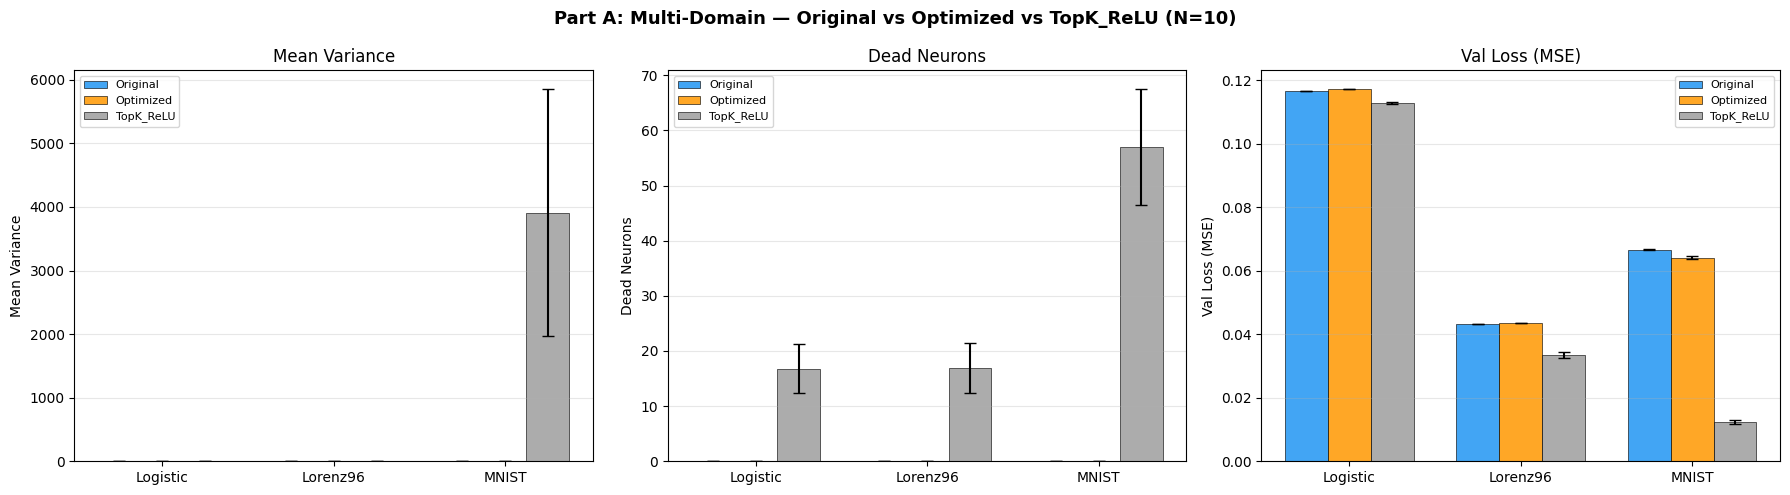

Saved: images/coefficient_combination_multidomain.png


In [ ]:
domain_names = list(domains.keys())
arch_names = list(architectures.keys())
colors = {'Original': '#2196F3', 'Optimized': '#FF9800', 'TopK_ReLU': '#9E9E9E'}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
metrics = [
    ('var_mean', 'var_std', 'Mean Variance'),
    ('dead_mean', 'dead_std', 'Dead Neurons'),
    ('loss_mean', 'loss_std', 'Val Loss (MSE)'),
]

x = np.arange(len(domain_names))
width = 0.25

for ax, (m_key, s_key, ylabel) in zip(axes, metrics):
    for i, arch in enumerate(arch_names):
        means = [summary_a_table[d][arch][m_key] for d in domain_names]
        stds = [summary_a_table[d][arch][s_key] for d in domain_names]
        ax.bar(x + i * width, means, width, yerr=stds,
               label=arch, color=colors[arch], capsize=4, alpha=0.85,
               edgecolor='black', linewidth=0.5)

    ax.set_xticks(x + width)
    ax.set_xticklabels(domain_names)
    ax.set_ylabel(ylabel)
    ax.set_title(ylabel)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3, axis='y')

plt.suptitle(
    f'Part A: Multi-Domain — Original vs Optimized vs TopK_ReLU (N={NUM_RUNS})',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.savefig('../images/coefficient_combination_multidomain.png',
            dpi=300, bbox_inches='tight')
plt.show()
print("Saved: images/coefficient_combination_multidomain.png")

---
## Part B: Dataset Scaling
---

In [ ]:
DATASET_SIZES = [2000, 5000, 10000, 20000]
BATCH_SIZE_B = 64

# Fixed test set
np.random.seed(999)
test_images_b = generate_logistic_dataset(500)
print(f"Test set: {test_images_b.shape}")

results_b = {'Original': {}, 'Optimized': {}}

configs_b = {
    'Original':  lambda: build_ksparse_ae(a=8.0, w=0.5, b=4.0,
                                          latent_dim=LATENT_DIM, k_active=K_ACTIVE),
    'Optimized': lambda: build_ksparse_ae(a=4.0, w=1.0, b=16.0,
                                          latent_dim=LATENT_DIM, k_active=K_ACTIVE),
}

for size in DATASET_SIZES:
    print(f"\n{'='*60}")
    print(f"DATASET SIZE: {size}")
    print(f"{'='*60}")

    np.random.seed(42)
    train_b = generate_logistic_dataset(size)
    print(f"Train: {train_b.shape}")

    for cfg_name, builder in configs_b.items():
        print(f"\n  --- {cfg_name} ---")
        results_b[cfg_name][size] = run_config(
            builder, train_b, test_images_b,
            f"{size}/{cfg_name}",
            batch_size=BATCH_SIZE_B
        )

print("\nPart B done.")

Test set: (500, 28, 28, 1)

DATASET SIZE: 2000
Train: (2000, 28, 28, 1)

  --- Original ---
  2000/Original                       run 1/10: var=0.4197, dead=  0/128, loss=0.1189
  2000/Original                       run 2/10: var=0.4185, dead=  0/128, loss=0.1189
  2000/Original                       run 3/10: var=0.4138, dead=  0/128, loss=0.1190
  2000/Original                       run 4/10: var=0.4123, dead=  0/128, loss=0.1188
  2000/Original                       run 5/10: var=0.4194, dead=  0/128, loss=0.1190
  2000/Original                       run 6/10: var=0.4191, dead=  0/128, loss=0.1190
  2000/Original                       run 7/10: var=0.4203, dead=  0/128, loss=0.1190
  2000/Original                       run 8/10: var=0.4173, dead=  0/128, loss=0.1188
  2000/Original                       run 9/10: var=0.4147, dead=  0/128, loss=0.1188
  2000/Original                       run 10/10: var=0.4193, dead=  0/128, loss=0.1190

  --- Optimized ---
  2000/Optimized          

In [ ]:
print(f"\n{'='*90}")
print(f"PART B: DATASET SCALING (N={NUM_RUNS} runs)")
print(f"{'='*90}")
print(f"  {'Size':>6} | {'Orig Variance':>16} | {'Opt Variance':>16} | "
      f"{'Ratio':>6} | {'p-value':>10} | {'Orig Loss':>10} | {'Opt Loss':>10}")
print(f"  {'-'*95}")

summary_b_rows = []

for size in DATASET_SIZES:
    orig = results_b['Original'][size]
    opt = results_b['Optimized'][size]

    ov = [r['mean_variance'] for r in orig]
    pv = [r['mean_variance'] for r in opt]
    ol = [r['val_loss'] for r in orig]
    pl = [r['val_loss'] for r in opt]
    od = [r['dead_neurons'] for r in orig]
    pd = [r['dead_neurons'] for r in opt]

    t_stat, p_val = stats.ttest_ind(ov, pv, equal_var=False)
    ratio = np.mean(pv) / np.mean(ov)
    sig = '***' if p_val < 0.001 else ('**' if p_val < 0.01 else ('*' if p_val < 0.05 else 'ns'))

    print(f"  {size:>6} | "
          f"{np.mean(ov):.4f} ± {np.std(ov):.4f} | "
          f"{np.mean(pv):.4f} ± {np.std(pv):.4f} | "
          f"{ratio:>5.2f}x | "
          f"{p_val:>8.6f} {sig:>3} | "
          f"{np.mean(ol):.4f}     | "
          f"{np.mean(pl):.4f}")

    summary_b_rows.append({
        'size': size,
        'orig_var': np.mean(ov), 'orig_var_std': np.std(ov),
        'opt_var': np.mean(pv), 'opt_var_std': np.std(pv),
        'orig_dead': np.mean(od), 'opt_dead': np.mean(pd),
        'orig_loss': np.mean(ol), 'opt_loss': np.mean(pl),
        'ratio': ratio, 'p_value': p_val,
    })


PART B: DATASET SCALING (N=10 runs)
    Size |    Orig Variance |     Opt Variance |  Ratio |    p-value |  Orig Loss |   Opt Loss
  -----------------------------------------------------------------------------------------------
    2000 | 0.4174 ± 0.0027 | 0.8015 ± 0.0074 |  1.92x | 0.000000 *** | 0.1189     | 0.1199
    5000 | 0.4142 ± 0.0036 | 0.7914 ± 0.0152 |  1.91x | 0.000000 *** | 0.1166     | 0.1173
   10000 | 0.4083 ± 0.0025 | 0.7731 ± 0.0066 |  1.89x | 0.000000 *** | 0.1168     | 0.1175
   20000 | 0.4013 ± 0.0028 | 0.7376 ± 0.0062 |  1.84x | 0.000000 *** | 0.1166     | 0.1172


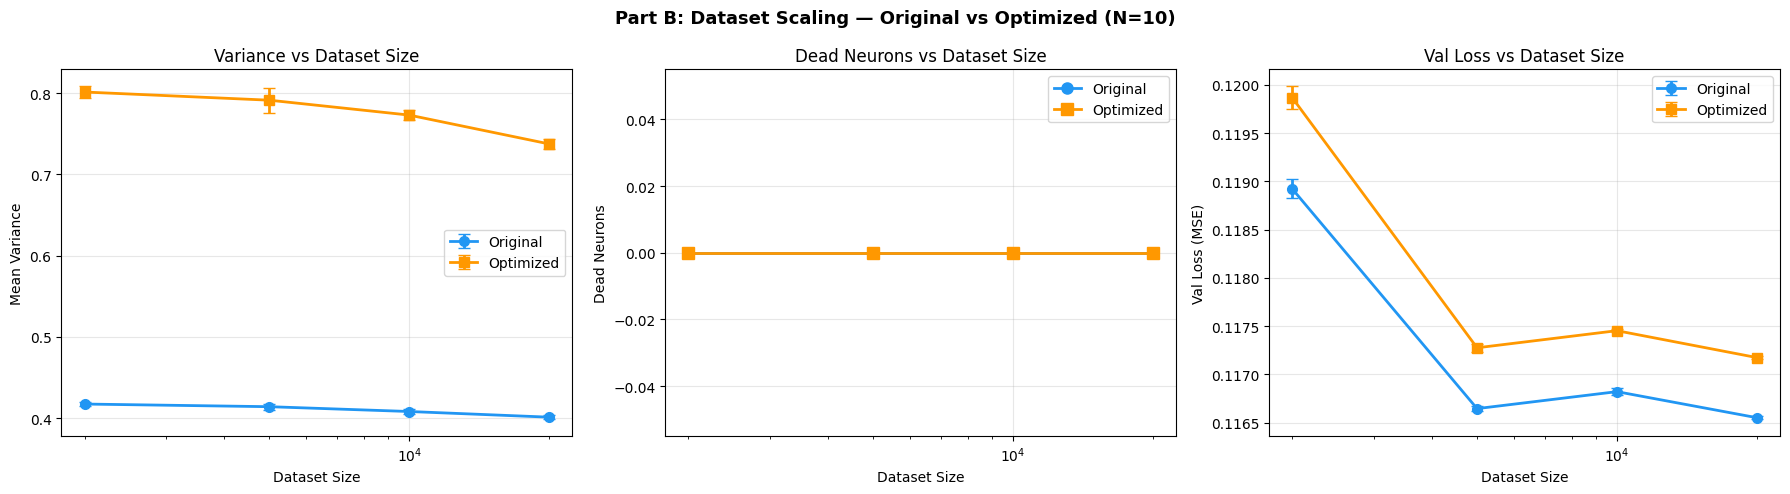

Saved: images/coefficient_combination_scaling.png


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sizes = DATASET_SIZES

for cfg_name, color, marker in [
    ('Original', '#2196F3', 'o'),
    ('Optimized', '#FF9800', 's'),
]:
    var_m = [np.mean([r['mean_variance'] for r in results_b[cfg_name][s]]) for s in sizes]
    var_s = [np.std([r['mean_variance'] for r in results_b[cfg_name][s]]) for s in sizes]
    dead_m = [np.mean([r['dead_neurons'] for r in results_b[cfg_name][s]]) for s in sizes]
    loss_m = [np.mean([r['val_loss'] for r in results_b[cfg_name][s]]) for s in sizes]
    loss_s = [np.std([r['val_loss'] for r in results_b[cfg_name][s]]) for s in sizes]

    axes[0].errorbar(sizes, var_m, yerr=var_s, marker=marker, label=cfg_name,
                     capsize=4, linewidth=2, markersize=7, color=color)
    axes[1].plot(sizes, dead_m, f'{marker}-', label=cfg_name,
                markersize=8, linewidth=2, color=color)
    axes[2].errorbar(sizes, loss_m, yerr=loss_s, marker=marker, label=cfg_name,
                     capsize=4, linewidth=2, markersize=7, color=color)

for ax, title, ylabel in zip(axes,
    ['Variance vs Dataset Size', 'Dead Neurons vs Dataset Size', 'Val Loss vs Dataset Size'],
    ['Mean Variance', 'Dead Neurons', 'Val Loss (MSE)']):
    ax.set_xlabel('Dataset Size')
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_xscale('log')

plt.suptitle(
    f'Part B: Dataset Scaling — Original vs Optimized (N={NUM_RUNS})',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.savefig('../images/coefficient_combination_scaling.png',
            dpi=300, bbox_inches='tight')
plt.show()
print("Saved: images/coefficient_combination_scaling.png")

In [ ]:
def runs_to_json(results_dict):
    out = {}
    for k, v in results_dict.items():
        if isinstance(v, dict):
            out[str(k)] = runs_to_json(v)
        elif isinstance(v, list):
            out[str(k)] = v
        else:
            out[str(k)] = v
    return out


save_data = {
    'experiment': 'coefficient_combination',
    'timestamp': datetime.now().isoformat(),
    'config': {
        'original': {'a': 8.0, 'w': 0.5, 'b': 4.0},
        'optimized': {'a': 4.0, 'w': 1.0, 'b': 16.0},
        'num_runs': NUM_RUNS,
        'epochs': EPOCHS,
        'latent_dim': LATENT_DIM,
        'k_active': K_ACTIVE,
    },
    'part_a': {
        'domains': domain_names,
        'results': runs_to_json(results_a),
        'summary': runs_to_json(summary_a_table),
    },
    'part_b': {
        'sizes': DATASET_SIZES,
        'results': runs_to_json(results_b),
        'summary': summary_b_rows,
    },
}

json_path = f'../jsons/coefficient_combination_{datetime.now().strftime("%Y%m%d_%H%M%S")}.json'
with open(json_path, 'w') as f:
    json.dump(save_data, f, indent=2, default=str)
print(f"Results saved: {json_path}")

Results saved: ../jsons/coefficient_combination_20260228_194649.json
